In [68]:
import numpy as np 
import matplotlib.pyplot as plt
from itertools import product
import itertools
from scipy.sparse import csr_matrix, kron, identity, diags
from scipy.sparse.linalg import eigsh
from scipy.linalg import expm, eigh

# Poor man's double dot

$$H_{2qd} = \sum_k \epsilon_k c^\dagger_k c_k + \sum_p \epsilon_p f^\dagger_p f_p + \sum_q \epsilon_q f^\dagger_q f_q +  \frac{1}{2}\vec{Q}^T (\vec{C}^{-1}) \vec{Q} +\phi_p \hat{Q}_p + \phi_q \hat{Q}_q + \sum_{p,q}[t_{pq} f^\dagger_p f_q + t^*_{qp}f^\dagger_q f_p] + \sum_{k,p} [t_{kp} c^\dagger_k f_p + t^*_{pk}f^\dagger_p c_k] + \sum_{k,q} [t_{kq} c^\dagger_k f_q + t^*_{qk}f^\dagger_q c_k]$$

In [111]:
class H_2qd:
    def __init__(self, phi_p, phi_q, t_pq, t_kp, t_kq, Nk, Np, Nq):
        self.phi_p, self.phi_q = phi_p, phi_q
        self.t_pq, self.t_kp, self.t_kq = t_pq, t_kp, t_kq
        self.Nk, self.Np, self.Nq = Nk, Np, Nq
        self.e_charge = -1.0
        self.C_p, self.C_q, self.C_pq = 1,1,0.3
        self.eps_k = np.linspace(-2, 2, Nk)
        self.eps_p = np.linspace(-1, 1, Np)
        self.eps_q = np.linspace(-1, 1, Nq)

        # Basis
        self._basis = [list(state) for state in product([0,1], repeat=Nk+Np+Nq)]
        self._state_to_index = {tuple(b): i for i, b in enumerate(self._basis)}
        self.dim = len(self._basis)

        # randomize tunnel amplitudes 
        rng = np.random.RandomState(1)
        self.tmat_pq = rng.normal(scale=t_pq, size=(Np, Nq))
        self.tmat_kp = rng.normal(scale=t_kp, size=(Nk, Np))
        self.tmat_kq = rng.normal(scale=t_kq, size=(Nk, Nq))

    def theta(self,x): 
        return 1.0 if x>0 else 0.0
    
    def fermion_sign(self, occ, m): 
        return -1 if sum(occ[:m])%2 else 1

    def ann_op(self, mode):
        rows, cols, data = [], [], []
        for b in self._basis:
            if b[mode]==1:
                new_b = b.copy(); new_b[mode]=0
                sign = self.fermion_sign(b, mode)
                i = self._state_to_index[tuple(b)]
                j = self._state_to_index[tuple(new_b)]
                rows.append(j); cols.append(i); data.append(sign)
        return csr_matrix((data,(rows,cols)),shape=(self.dim,self.dim),dtype=np.complex128)

    def ann_ops(self): return [self.ann_op(m) for m in range(self.Nk+self.Np+self.Nq)]
    def num_ops(self): return [diags([b[m] for b in self._basis], format='csr') for m in range(self.Nk+self.Np+self.Nq)]

    def lead(self): 
        return sum(self.eps_k[k]*self.num_ops()[k] for k in range(self.Nk))
    
    def p(self):    
        return sum(self.eps_p[p]*self.num_ops()[self.Nk+p] for p in range(self.Np))
    
    def q(self):    
        return sum(self.eps_q[q]*self.num_ops()[self.Nk+self.Np+q] for q in range(self.Nq))
    
    def N_p_op(self): 
        return sum(self.num_ops()[self.Nk+p] for p in range(self.Np))
    
    def N_q_op(self): 
        return sum(self.num_ops()[self.Nk+self.Np+q] for q in range(self.Nq))

    def Q_p_op(self):
        N0 = sum(self.theta(ep) for ep in self.eps_p)
        return self.e_charge * (self.N_p_op() - N0 * identity(self.dim, format='csr'))
    
    def Q_q_op(self):
        N0 = sum(self.theta(eq) for eq in self.eps_q)
        return self.e_charge * (self.N_q_op() - N0 * identity(self.dim, format='csr'))

    def gate(self): 
        # need to include lever arm here 
        return self.phi_p*self.Q_p_op() + self.phi_q*self.Q_q_op() + self.phi_p*(0/self.C_p)*self.Q_q_op() + self.phi_q*(0/self.C_q)*self.Q_p_op()

    def Coulomb(self):
        Qp, Qq = self.Q_p_op(), self.Q_q_op()
        return self.C_q*(Qp@Qp)/(self.C_q*self.C_p-self.C_pq) + self.C_p*(Qq@Qq)/(self.C_q*self.C_p-self.C_pq)  + self.C_pq*(Qp@Qq + Qq@Qp)/(self.C_q*self.C_p-self.C_pq)

    def tunnel_pq(self):
        H = csr_matrix((self.dim,self.dim),dtype=np.complex128)
        a_ops, c_ops = self.ann_ops(), [op.getH() for op in self.ann_ops()]
        for p in range(self.Np):
            for q in range(self.Nq):
                dotp, dotq = self.Nk+p, self.Nk+self.Np+q
                t = self.tmat_pq[p,q]
                H += t*(c_ops[dotp]@a_ops[dotq]) + np.conjugate(t)*(c_ops[dotq]@a_ops[dotp])
        return H

    def tunnel_kp(self):
        H = csr_matrix((self.dim,self.dim),dtype=np.complex128)
        a_ops, c_ops = self.ann_ops(), [op.getH() for op in self.ann_ops()]
        for k in range(self.Nk):
            for p in range(self.Np):
                lead, grain = k, self.Nk+p
                t = self.tmat_kp[k,p]
                H += t*(c_ops[lead]@a_ops[grain]) + np.conjugate(t)*(c_ops[grain]@a_ops[lead])
        return H

    def tunnel_kq(self):
        H = csr_matrix((self.dim,self.dim),dtype=np.complex128)
        a_ops, c_ops = self.ann_ops(), [op.getH() for op in self.ann_ops()]
        for k in range(self.Nk):
            for q in range(self.Nq):
                lead, grain = k, self.Nk+self.Np+q
                t = self.tmat_kq[k,q]
                H += t*(c_ops[lead]@a_ops[grain]) + np.conjugate(t)*(c_ops[grain]@a_ops[lead])
        return H

    def total(self):
        return self.lead() + self.p() + self.q() + self.Coulomb() + self.gate() + self.tunnel_pq() + self.tunnel_kp() + self.tunnel_kq()

In [112]:
H = H_2qd(phi_p=0.0, phi_q=0.0, t_pq=0.1, t_kp=0.1, t_kq=0.1, Nk=2, Np=2, Nq=2)
vals, vecs = eigsh(H.total(), k=1, which='SA')

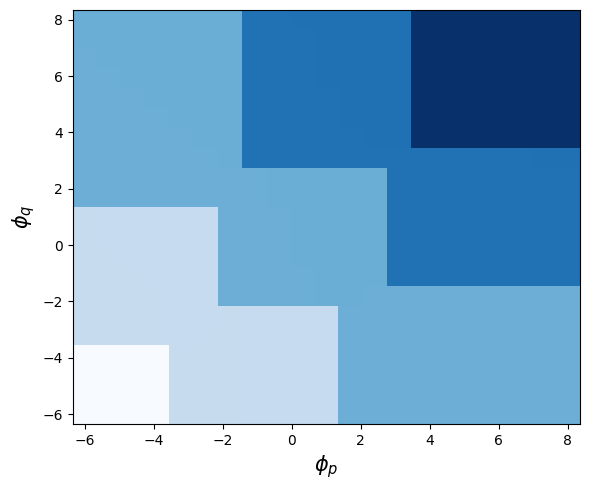

In [113]:
phi_p_list = np.linspace(-6, 8, 21)
phi_q_list = np.linspace(-6, 8, 21)
N_vs_phi = np.zeros((len(phi_p_list), len(phi_q_list)))

# Loop over the 2D parameter space
for i, phi_pp in enumerate(phi_p_list):
    for j, phi_qq in enumerate(phi_q_list):
        H = H_2qd(phi_p=phi_pp, phi_q=phi_qq, 
                  t_pq=0.02, t_kp=0.02, t_kq=0.02, 
                  Nk=2, Np=2, Nq=2)
        val, vec = eigsh(H.total(), k=1, which='SA')
        gs = vec[:, 0]
        Ncharge = np.real(gs.conj().T @ (H.N_q_op()+H.N_p_op()) @ gs) 
        N_vs_phi[i, j] = Ncharge

# Make color plot
fig, ax = plt.subplots(figsize=(6,5), layout='tight')

c = ax.pcolormesh(phi_p_list, phi_q_list, N_vs_phi.T, shading='auto', cmap='Blues')
ax.set_xlabel(r'$\phi_p$', fontsize = 15)
ax.set_ylabel(r'$\phi_q$', fontsize = 15)

plt.show()

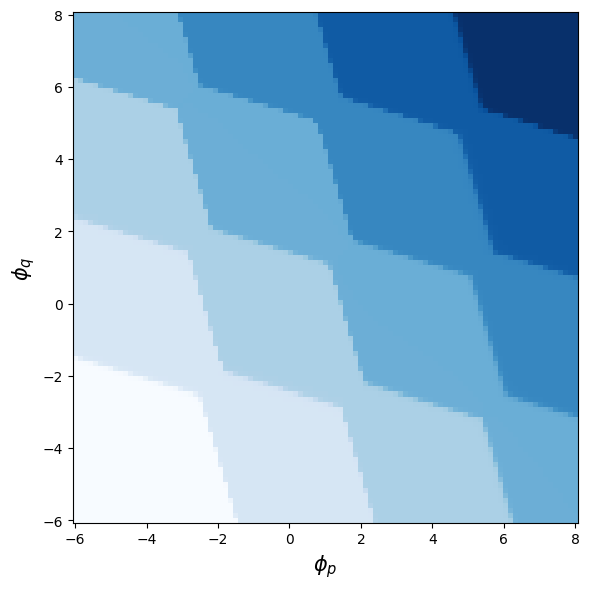

In [74]:
fig, ax = plt.subplots(figsize=(6,6), layout='tight')

c = ax.pcolormesh(phi_p_list, phi_q_list, N_vs_phi.T, shading='auto', cmap='Blues')
ax.set_xlabel(r'$\phi_p$', fontsize = 15)
ax.set_ylabel(r'$\phi_q$', fontsize = 15)

plt.show()

In [116]:
class H_2qd:
    def __init__(self, phi_p, phi_q, t_pq, t_kp, t_kq, Nk, Np, Nq):
        self.phi_p, self.phi_q          = phi_p, phi_q
        self.t_pq, self.t_kp, self.t_kq = t_pq, t_kp, t_kq
        self.Nk, self.Np, self.Nq       = Nk, Np, Nq
        self.e_charge = -1.0
        self.eps_k = np.linspace(-1, 1, Nk)
        self.eps_p = np.linspace(-1, 1, Np)
        self.eps_q = np.linspace(-1, 1, Nq)

        # Basis
        self._basis = [list(state) for state in product([0,1], repeat=Nk+Np+Nq)]
        self._state_to_index = {tuple(b): i for i, b in enumerate(self._basis)}
        self.dim = len(self._basis)

        # randomize tunnel amplitudes 
        rng = np.random.RandomState(1)
        self.tmat_pq = rng.normal(scale=t_pq, size=(Np, Nq))
        self.tmat_kp = rng.normal(scale=t_kp, size=(Nk, Np))
        self.tmat_kq = rng.normal(scale=t_kq, size=(Nk, Nq))

    def set_Cmtx(self, Cdd, Cgd):
        self.Cdd = np.asarray(Cdd)
        self.Cgd = np.asarray(Cgd)

    def theta(self,x): 
        return 1.0 if x>0 else 0.0
    
    def fermion_sign(self, occ, m): 
        return -1 if sum(occ[:m])%2 else 1

    def ann_op(self, mode):
        rows, cols, data = [], [], []
        for b in self._basis:
            if b[mode]==1:
                new_b = b.copy(); new_b[mode]=0
                sign = self.fermion_sign(b, mode)
                i = self._state_to_index[tuple(b)]
                j = self._state_to_index[tuple(new_b)]
                rows.append(j); cols.append(i); data.append(sign)
        return csr_matrix((data,(rows,cols)),shape=(self.dim,self.dim),dtype=np.complex128)

    def ann_ops(self): 
        return [self.ann_op(m) for m in range(self.Nk+self.Np+self.Nq)]
    
    def num_ops(self): 
        return [diags([b[m] for b in self._basis], format='csr') for m in range(self.Nk+self.Np+self.Nq)]

    def lead(self): 
        return sum(self.eps_k[k]*self.num_ops()[k] for k in range(self.Nk))
    
    def p(self):    
        return sum(self.eps_p[p]*self.num_ops()[self.Nk+p] for p in range(self.Np))
    
    def q(self):    
        return sum(self.eps_q[q]*self.num_ops()[self.Nk+self.Np+q] for q in range(self.Nq))
    
    def N_p_op(self): 
        return sum(self.num_ops()[self.Nk+p] for p in range(self.Np))
    
    def N_q_op(self): 
        return sum(self.num_ops()[self.Nk+self.Np+q] for q in range(self.Nq))

    def Q_p_op(self):
        N0 = sum(self.theta(ep) for ep in self.eps_p)
        return self.e_charge * (self.N_p_op() - N0 * identity(self.dim, format='csr'))
    
    def Q_q_op(self):
        N0 = sum(self.theta(eq) for eq in self.eps_q)
        return self.e_charge * (self.N_q_op() - N0 * identity(self.dim, format='csr'))

    def gate(self): 
        Qvec   = np.array([self.Q_p_op(), self.Q_q_op()])
        phivec = np.array([self.phi_p, self.phi_q])
        lever  = np.diag(np.diag(np.linalg.inv(self.Cdd)))@self.Cgd@phivec.T
        return np.dot(lever, Qvec)
    

    def Coulomb(self):
        Qvec   = np.array([self.Q_p_op(), self.Q_q_op()])
        return 0.5*np.array(Qvec)@np.linalg.inv(self.Cdd) @ np.array(Qvec).T

    def tunnel_pq(self):
        H = csr_matrix((self.dim,self.dim),dtype=np.complex128)
        a_ops, c_ops = self.ann_ops(), [op.getH() for op in self.ann_ops()]
        for p in range(self.Np):
            for q in range(self.Nq):
                dotp, dotq = self.Nk+p, self.Nk+self.Np+q
                t = self.tmat_pq[p,q]
                H += t*(c_ops[dotp]@a_ops[dotq]) + np.conjugate(t)*(c_ops[dotq]@a_ops[dotp])
        return H

    def tunnel_kp(self):
        H = csr_matrix((self.dim,self.dim),dtype=np.complex128)
        a_ops, c_ops = self.ann_ops(), [op.getH() for op in self.ann_ops()]
        for k in range(self.Nk):
            for p in range(self.Np):
                lead, grain = k, self.Nk+p
                t = self.tmat_kp[k,p]
                H += t*(c_ops[lead]@a_ops[grain]) + np.conjugate(t)*(c_ops[grain]@a_ops[lead])
        return H

    def tunnel_kq(self):
        H = csr_matrix((self.dim,self.dim),dtype=np.complex128)
        a_ops, c_ops = self.ann_ops(), [op.getH() for op in self.ann_ops()]
        for k in range(self.Nk):
            for q in range(self.Nq):
                lead, grain = k, self.Nk+self.Np+q
                t = self.tmat_kq[k,q]
                H += t*(c_ops[lead]@a_ops[grain]) + np.conjugate(t)*(c_ops[grain]@a_ops[lead])
        return H

    def total(self):
        return self.lead() + self.p() + self.q() + self.Coulomb() + self.gate() + self.tunnel_pq() + self.tunnel_kp() + self.tunnel_kq()

In [78]:
H = H_2qd(phi_p=0.0, phi_q=0.0, t_pq=0.1, t_kp=0.1, t_kq=0.1, Nk=2, Np=2, Nq=2)
H.set_Cmtx(Cdd=[[1.0, 0.3],[0.3, 1.0]], Cgd=[[0.5, 0.0],[0.0, 0.5]])

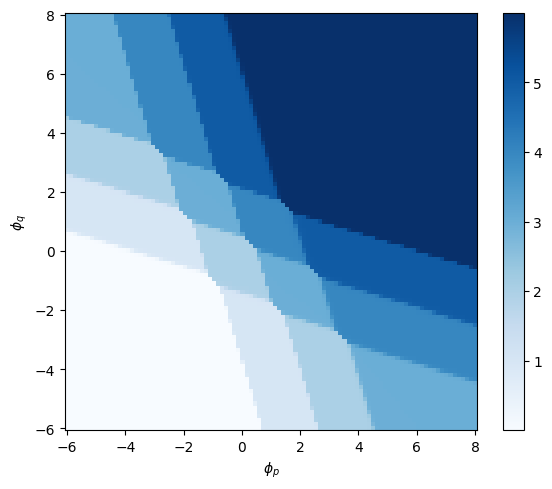

In [121]:
phi_p_list = np.linspace(-6, 8, 101)
phi_q_list = np.linspace(-6, 8, 101)
N_vs_phi = np.zeros((len(phi_p_list), len(phi_q_list)))

# Loop over the 2D parameter space
for i, phi_pp in enumerate(phi_p_list):
    for j, phi_qq in enumerate(phi_q_list):
        H = H_2qd(phi_p=phi_pp, phi_q=phi_qq, 
                  t_pq=0.02, t_kp=0.02, t_kq=0.02, 
                  Nk=3, Np=3, Nq=3)
        H.set_Cmtx(Cdd=[[1.0, 0.3],[0.3, 1.0]], Cgd=[[1, 0.3],[0.3, 1]])
        val, vec = eigsh(H.total(), k=1, which='SA')
        gs = vec[:, 0]
        Ncharge = np.real(gs.conj().T @ (H.N_q_op()+H.N_p_op()) @ gs) 
        N_vs_phi[i, j] = Ncharge

# Make color plot
fig, ax = plt.subplots(figsize=(6,5), layout='tight')

c = ax.pcolormesh(phi_p_list, phi_q_list, N_vs_phi.T, shading='auto', cmap='Blues')
ax.set_xlabel(r'$\phi_p$')
ax.set_ylabel(r'$\phi_q$')
fig.colorbar(c, ax=ax)

plt.show()